# Full Transformer Encoder: Training on SST-2

Read [The Annotated Transformer](https://nlp.seas.harvard.edu/2018/04/03/attention.html).

**Goal:** Assemble a complete transformer encoder, train from scratch on Stanford Sentiment Treebank (binary sentiment classification), achieve >80% validation accuracy.

## Full Architecture

```
Input tokens → Token Embedding → + Positional Encoding → Dropout
    → [TransformerEncoderBlock × N]
    → LayerNorm (final)
    → CLS token pooling or mean pooling
    → Linear classifier → logits
```

Components (all implemented in previous notebooks):
- Token embedding: `nn.Embedding(vocab_size, d_model)`
- Positional encoding: sinusoidal (notebook 03)
- $N$ encoder blocks, each with MHA + FFN + residual + LayerNorm (notebook 04)
- Classification head: `Linear(d_model, n_classes)`

Hyperparameters (Transformer-small for this task):
- `d_model = 128`
- `n_heads = 4` ($d_k = 32$)
- `d_ff = 512` ($4 \times d_{\text{model}}$)
- `n_layers = 4`
- `dropout = 0.1`
- `max_len = 128`

## Learning Rate Schedule: Warmup + Cosine Decay

The original Transformer uses:

$$lr = d_{\text{model}}^{-0.5} \cdot \min(\text{step}^{-0.5},\; \text{step} \cdot \text{warmup\_steps}^{-1.5})$$

**Warmup phase** (step < warmup_steps): LR increases linearly from 0.

**Decay phase** (step $\geq$ warmup_steps): LR decreases as $\text{step}^{-0.5}$.

**Why warmup?** At initialization, attention weights are random $\rightarrow$ gradients can be noisy and large. Small initial LR prevents early divergence. After warmup, the model is in a stable region and can tolerate larger steps.

We'll use a simpler variant: **linear warmup + cosine decay**.

## Loss Function: Cross-Entropy for Classification

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(z_{y_i})}{\sum_j \exp(z_j)}$$

Where $z$ are the logits from the classifier head and $y_i$ is the true class. PyTorch's `F.cross_entropy` handles this efficiently (log-softmax + NLL combined).

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from datasets import load_dataset
from transformers import AutoTokenizer

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
# --- From Notebook 01: Scaled Dot-Product Attention ---
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


# --- From Notebook 02: Multi-Head Attention ---
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        Q = self.W_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_output = self.dropout(attn_output)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(attn_output), attn_weights


# --- From Notebook 03: Positional Encoding ---
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# --- From Notebook 04: Encoder Block ---
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.norm1(x)
        attn_output, _ = self.attention(normed, normed, normed, mask)
        x = x + self.dropout(attn_output)
        normed = self.norm2(x)
        ff_output = self.feed_forward(normed)
        x = x + self.dropout(ff_output)
        return x

## Implementation: Full Transformer Encoder

In [15]:
class TransformerEncoder(nn.Module):
    """
    Full Transformer encoder for sequence classification.

    Architecture:
        Token Embedding + Positional Encoding + Dropout
        -> N x TransformerEncoderBlock
        -> Final LayerNorm
        -> Mean pooling over sequence
        -> Linear classifier

    Args:
        vocab_size: size of vocabulary
        d_model: model dimension (128)
        n_heads: number of attention heads (4)
        d_ff: FFN hidden dimension (512)
        n_layers: number of encoder blocks (4)
        n_classes: number of output classes (2 for SST-2)
        max_len: maximum sequence length (128)
        dropout: dropout rate (0.1)
    """
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers,
                 n_classes, max_len=128, dropout=0.1):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)

        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len)

        self.dropout = nn.Dropout(dropout)

        # Stack of encoder blocks
        self.layers = nn.ModuleList([TransformerEncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        self.final_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Linear(d_model, n_classes)

        self._init_weights()

    def _init_weights(self):
        """Xavier uniform initialization for embeddings."""
        nn.init.xavier_uniform_(self.token_embedding.weight)

    def forward(self, input_ids, attention_mask=None):
        """
        Args:
            input_ids: (batch, seq_len) token indices
            attention_mask: (batch, seq_len) -- 1 for real tokens, 0 for padding

        Returns:
            logits: (batch, n_classes)
        """
        # Create embedding: token_embed * sqrt(d_model) + pos_encoding
        # Scaling by sqrt(d_model)
        # Intuition: embeddings are learned with small values, scaling brings them
        # to same magnitude as positional encodings
        x = self.token_embedding(input_ids) * (self.token_embedding.embedding_dim ** 0.5)
        x = self.dropout(x)
        # Convert attention_mask to the right shape for multi-head attention
        # From (batch, seq_len) -> (batch, 1, 1, seq_len) for broadcasting
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
        else:
            mask = None

        # Pass through encoder blocks
        for layer in self.layers:
            x = layer(x, mask)

        # Final normalization
        x = self.final_norm(x)

        # Pool over sequence dimension
        # Mean pooling: average token representations (use attention_mask to exclude padding)
        if attention_mask is not None:
            # Mask out padding tokens before averaging
            mask_expanded = attention_mask.unsqueeze(-1).float()  # (batch, seq_len, 1)
            x = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1)
        else:
            x = x.mean(dim=1)

        # Classify
        logits = self.classifier(x)

        return logits

## Dataset: SST-2

In [16]:
# Load SST-2 dataset
dataset = load_dataset("stanfordnlp/sst2")
print(f"Train: {len(dataset['train'])} samples")
print(f"Validation: {len(dataset['validation'])} samples")
print(f"\nSample: {dataset['train'][0]}")

# Use a pre-trained tokenizer for preprocessing
# (Learning focus is on the model, not tokenization)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 128


class SST2Dataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len=128):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        encoding = self.tokenizer(
            item['sentence'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(item['label'], dtype=torch.long)
        }


train_dataset = SST2Dataset(dataset['train'], tokenizer, MAX_LEN)
val_dataset = SST2Dataset(dataset['validation'], tokenizer, MAX_LEN)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Verify a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  input_ids: {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  labels: {batch['label'].shape}")

Train: 67349 samples
Validation: 872 samples

Sample: {'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}

Batch shapes:
  input_ids: torch.Size([32, 128])
  attention_mask: torch.Size([32, 128])
  labels: torch.Size([32])


In [17]:
# Hyperparameters
VOCAB_SIZE = tokenizer.vocab_size
D_MODEL = 128
N_HEADS = 4
D_FF = 512
N_LAYERS = 4
N_CLASSES = 2
MAX_LEN = 128
DROPOUT = 0.1

model = TransformerEncoder(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    n_classes=N_CLASSES,
    max_len=MAX_LEN,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Quick forward pass test
test_batch = next(iter(train_loader))
with torch.no_grad():
    logits = model(test_batch['input_ids'].to(device), test_batch['attention_mask'].to(device))
    print(f"Output logits shape: {logits.shape}")  # (batch_size, 2)

Total parameters: 4,700,418
Trainable parameters: 4,700,418
Output logits shape: torch.Size([32, 2])


## Learning Rate Schedule

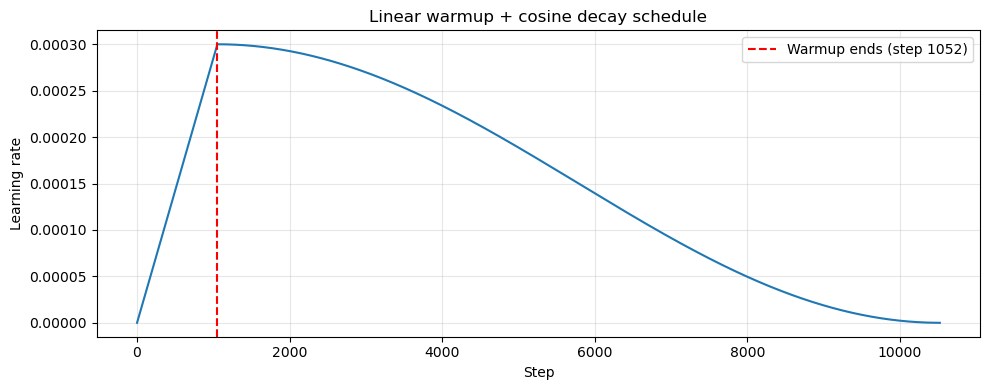

In [18]:
def get_lr_scheduler(optimizer, warmup_steps, total_steps):
    """Linear warmup + cosine decay."""
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Visualize the schedule
EPOCHS = 5
TOTAL_STEPS = len(train_loader) * EPOCHS
WARMUP_STEPS = int(0.1 * TOTAL_STEPS)  # 10% warmup

dummy_opt = torch.optim.Adam([torch.tensor(1.0)], lr=3e-4)
dummy_sched = get_lr_scheduler(dummy_opt, WARMUP_STEPS, TOTAL_STEPS)

lrs = []
for step in range(TOTAL_STEPS):
    lrs.append(dummy_sched.get_last_lr()[0])
    dummy_opt.step()
    dummy_sched.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.axvline(WARMUP_STEPS, color='r', linestyle='--', label=f'Warmup ends (step {WARMUP_STEPS})')
plt.xlabel('Step')
plt.ylabel('Learning rate')
plt.title('Linear warmup + cosine decay schedule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Training Loop

In [19]:
# Optimizer: AdamW (Adam with decoupled weight decay)
LR = 3e-4
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_lr_scheduler(optimizer, WARMUP_STEPS, TOTAL_STEPS)


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc='Training', leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=-1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        loss = F.cross_entropy(logits, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=-1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


# Training loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []
lrs_actual = []

print(f"Training for {EPOCHS} epochs ({TOTAL_STEPS} steps)")
print(f"Warmup: {WARMUP_STEPS} steps")
print("-" * 60)

for epoch in range(EPOCHS):
    start = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler)
    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.0f}s) | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Training for 5 epochs (10525 steps)
Warmup: 1052 steps
------------------------------------------------------------


Epoch 1/5 (113s) | Train loss: 0.3738, acc: 0.8301 | Val loss: 0.4461, acc: 0.8028


Epoch 2/5 (63s) | Train loss: 0.1940, acc: 0.9277 | Val loss: 0.5438, acc: 0.7982


Epoch 3/5 (63s) | Train loss: 0.1192, acc: 0.9567 | Val loss: 0.6644, acc: 0.8028


Epoch 4/5 (86s) | Train loss: 0.0787, acc: 0.9716 | Val loss: 0.8193, acc: 0.8005


Epoch 5/5 (128s) | Train loss: 0.0550, acc: 0.9802 | Val loss: 0.9802, acc: 0.7993


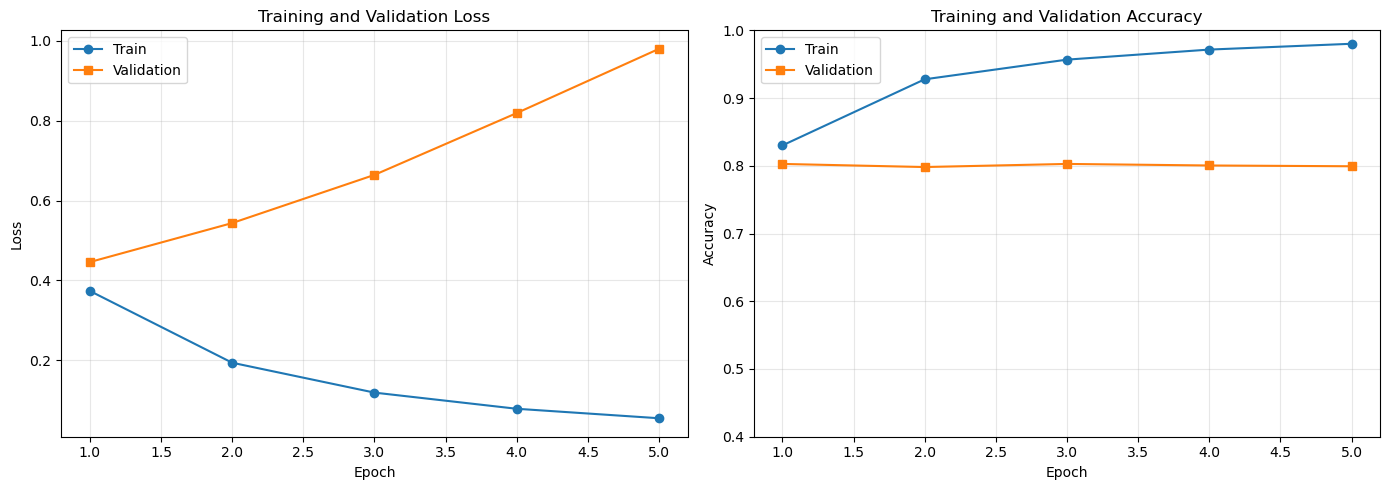


Best validation accuracy: 0.8028 (epoch 1)


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, 'o-', label='Train')
ax1.plot(range(1, EPOCHS+1), val_losses, 's-', label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), train_accs, 'o-', label='Train')
ax2.plot(range(1, EPOCHS+1), val_accs, 's-', label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.show()

print(f"\nBest validation accuracy: {max(val_accs):.4f} (epoch {np.argmax(val_accs)+1})")

## Experiment: Attention Visualization on Real Sentences

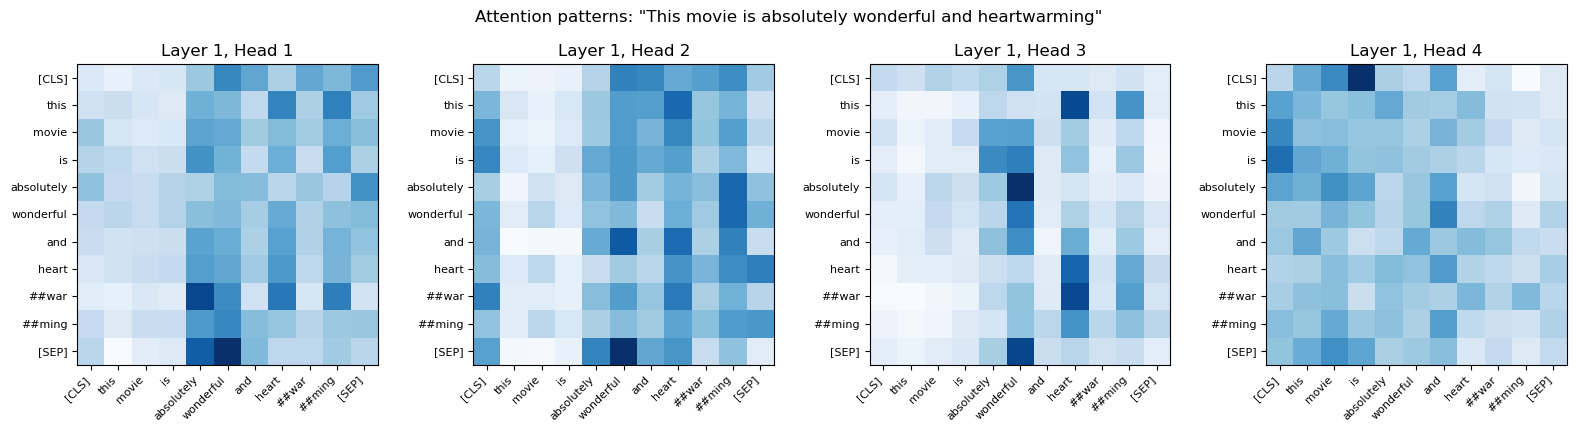

In [21]:
def get_attention_weights(model, text, tokenizer):
    """Extract attention weights from all layers for a given text."""
    encoding = tokenizer(text, return_tensors='pt', max_length=MAX_LEN,
                         padding='max_length', truncation=True)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()

    # Collect attention weights from each layer
    all_weights = []

    x = model.token_embedding(input_ids) * np.sqrt(model.token_embedding.embedding_dim)
    x = model.pos_encoding(x)
    x = model.dropout(x)

    mask = attention_mask.unsqueeze(1).unsqueeze(2)

    with torch.no_grad():
        for layer in model.layers:
            normed = layer.norm1(x)
            _, attn_weights = layer.attention(normed, normed, normed, mask)
            all_weights.append(attn_weights.cpu())

            attn_out, _ = layer.attention(normed, normed, normed, mask)
            x = x + layer.dropout(attn_out)
            normed = layer.norm2(x)
            x = x + layer.dropout(layer.feed_forward(normed))

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    seq_len = attention_mask[0].sum().item()
    tokens = tokens[:seq_len]

    return all_weights, tokens


# Visualize attention for a sample sentence
sample_text = "This movie is absolutely wonderful and heartwarming"
weights, tokens = get_attention_weights(model, sample_text, tokenizer)

# Plot first layer, all heads
n_heads = weights[0].shape[1]
fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))

for h in range(n_heads):
    ax = axes[h]
    w = weights[0][0, h, :len(tokens), :len(tokens)].numpy()
    ax.imshow(w, cmap='Blues')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Layer 1, Head {h+1}')

plt.suptitle(f'Attention patterns: "{sample_text}"', y=1.02)
plt.tight_layout()
plt.show()

## Experiment: Comparison to DistilBERT Baseline

How does our tiny from-scratch transformer compare to a pre-trained model?

In [22]:
from transformers import AutoModelForSequenceClassification

# Load pre-trained DistilBERT (already fine-tuned on SST-2)
distilbert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
).to(device)
distilbert.eval()

distilbert_params = sum(p.numel() for p in distilbert.parameters())

# Evaluate DistilBERT on validation set
correct = 0
total = 0
with torch.no_grad():
    for batch in tqdm(val_loader, desc='DistilBERT eval', leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = distilbert(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

distilbert_acc = correct / total

print(f"{'Model':<30} {'Params':>12} {'Val Acc':>10}")
print("-" * 55)
print(f"{'Our Transformer (from scratch)':<30} {total_params:>12,} {max(val_accs):>10.4f}")
print(f"{'DistilBERT (pre-trained)':<30} {distilbert_params:>12,} {distilbert_acc:>10.4f}")
print(f"\nParameter ratio: {distilbert_params / total_params:.1f}x more in DistilBERT")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model                                Params    Val Acc
-------------------------------------------------------
Our Transformer (from scratch)    4,700,418     0.8028
DistilBERT (pre-trained)         66,955,010     0.9106

Parameter ratio: 14.2x more in DistilBERT


## Error Analysis

In [23]:
# Collect predictions and find errors
model.eval()
all_preds, all_labels, all_texts = [], [], []

with torch.no_grad():
    for i in range(len(val_dataset)):
        item = dataset['validation'][i]
        encoding = tokenizer(item['sentence'], return_tensors='pt', max_length=MAX_LEN,
                             padding='max_length', truncation=True)

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        logits = model(input_ids, attention_mask)
        pred = logits.argmax(dim=-1).item()

        all_preds.append(pred)
        all_labels.append(item['label'])
        all_texts.append(item['sentence'])

# Find misclassified examples
errors = [(t, l, p) for t, l, p in zip(all_texts, all_labels, all_preds) if l != p]
print(f"Errors: {len(errors)} / {len(all_labels)} ({len(errors)/len(all_labels):.1%})")
print("\nSample misclassifications:")
print("-" * 80)
for text, true_label, pred_label in errors[:10]:
    label_map = {0: 'negative', 1: 'positive'}
    print(f"Text: {text[:80]}...")
    print(f"True: {label_map[true_label]}, Predicted: {label_map[pred_label]}")
    print()

Errors: 175 / 872 (20.1%)

Sample misclassifications:
--------------------------------------------------------------------------------
Text: we root for ( clara and paul ) , even like them , though perhaps it 's an emotio...
True: positive, Predicted: negative

Text: pumpkin takes an admirable look at the hypocrisy of political correctness , but ...
True: negative, Predicted: positive

Text: holden caulfield did it better . ...
True: negative, Predicted: positive

Text: ... designed to provide a mix of smiles and tears , `` crossroads '' instead pro...
True: negative, Predicted: positive

Text: if the movie succeeds in instilling a wary sense of ` there but for the grace of...
True: negative, Predicted: positive

Text: the subtle strength of `` elling '' is that it never loses touch with the realit...
True: positive, Predicted: negative

Text: manages to be both repulsively sadistic and mundane . ...
True: negative, Predicted: positive

Text: it 's just disappointingly superficial -- a

## Connections

- Model is tiny (~1-2M params) vs BERT-base (110M) vs GPT-3 (175B)
- Pre-training on large corpora (masked LM, next token prediction) gives models a huge head start
- Model has to learn everything from 67k labeled sentences
- **Key insight:** the architecture is the same. Pre-training + scale is what makes modern models powerful.
- The gap between model and DistilBERT shows the value of pre-training
- Next steps: try increasing `d_model`, `n_layers`; try different pooling (CLS token); try pre-training on unlabeled text